# Hump Algebra

## Overview

Gaussian humps $G_z(x)=e^{-\|x-z\|^2/(2\sigma^2)}$ provide a flexible basis for smooth signed fields.
Finite signed sums
$$
f(x)=\sum_i a_i G_{z_i}(x),\qquad g(x)=\sum_j b_j G_{w_j}(x)
$$
are stable under **sum** and **product**, so they form a practical algebraic model class.

## Product identity

For two Gaussians, the product is another Gaussian up to a scalar factor:
$$
G_{z_1}(x)G_{z_2}(x)=C(z_1,z_2)\,\widetilde G_{z_1,z_2}(x).
$$
This notebook focuses on that closure property and on signed-mixture interactions.

We do not develop the Fourier-side algebra here, but recall that pointwise products correspond to convolutions after Fourier transform.


### Environment setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

### Gaussian bump function

We define the 2D Gaussian bump $G_z(x) = e^{-\|x-z\|^2/(2\sigma^2)}$ evaluated on a grid.

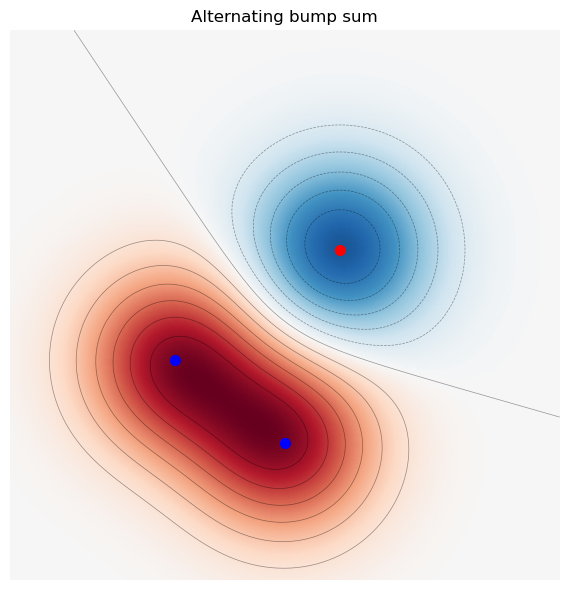

In [2]:
n = 300
t = np.linspace(0, 1, n)
Y, X = np.meshgrid(t, t)
sigma = 0.12

def gaussian_bump(center, sigma=sigma):
    """2D Gaussian bump centered at complex number center."""
    zr, zi = center.real, center.imag
    return np.exp(-((X - zr)**2 + (Y - zi)**2) / (2 * sigma**2))

def bump_field(centers, signs, sigma=sigma):
    """Alternating sum of Gaussian bumps: sum_i sign_i * G_{z_i}."""
    M = np.zeros((n, n))
    for z, s in zip(centers, signs):
        M += s * gaussian_bump(z, sigma)
    return M

def plot_bump_field(M, title, ax=None, centers=None, signs=None):
    if ax is None: fig, ax = plt.subplots(figsize=(5,5))
    r = 15
    vmax = np.abs(M).max()
    ax.imshow(M.T, extent=[0,1,0,1], origin='lower', cmap='RdBu_r',
              vmin=-vmax, vmax=vmax)
    ax.contour(X, Y, M, levels=np.linspace(-vmax, vmax, r), colors='k',
               linewidths=0.5, alpha=0.4)
    if centers is not None:
        for z, s in zip(centers, signs):
            c_col = 'blue' if s > 0 else 'red'
            ax.plot(z.real, z.imag, '.', color=c_col, ms=14)
    ax.set_title(title); ax.axis('off')

# Simple example: 3 bumps with alternating signs
rng = np.random.default_rng(42)
centers_a = [0.3+0.4j, 0.6+0.6j, 0.5+0.25j]
signs_a = [1, -1, 1]
Ma = bump_field(centers_a, signs_a)

fig, ax = plt.subplots(figsize=(6, 6))
plot_bump_field(Ma, 'Alternating bump sum', ax=ax, centers=centers_a, signs=signs_a)
plt.tight_layout(); plt.savefig('bumps_simple.png', dpi=100, bbox_inches='tight'); plt.show()

### Product of two signed mixtures

We compute $P = M_1\cdot M_2$ for two signed mixtures and inspect how positive/negative components interact under multiplication.


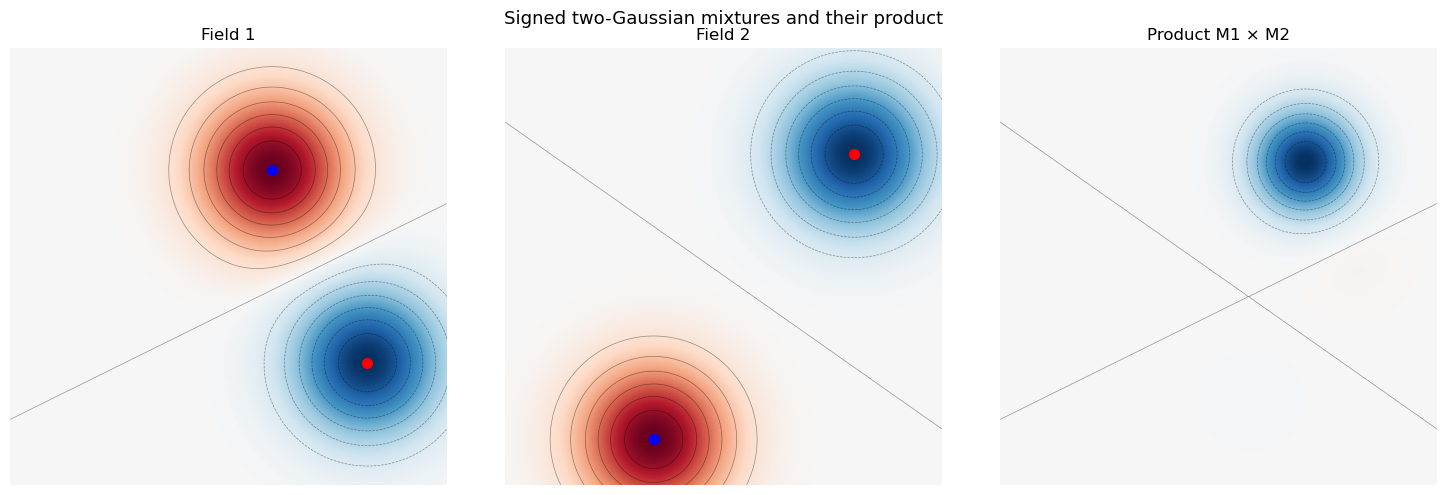

In [3]:
rng2 = np.random.default_rng(7)

# Two sets of bumps
n_bumps = 2
centers1 = rng2.uniform(0.1, 0.9, n_bumps) + 1j * rng2.uniform(0.1, 0.9, n_bumps)
signs1 = np.array([1, -1])

centers2 = rng2.uniform(0.1, 0.9, n_bumps) + 1j * rng2.uniform(0.1, 0.9, n_bumps)
signs2 = np.array([1, -1])

M1 = bump_field(centers1, signs1)
M2 = bump_field(centers2, signs2)
P = M1 * M2


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_bump_field(M1, 'Field 1', ax=axes[0], centers=centers1, signs=signs1)
plot_bump_field(M2, 'Field 2', ax=axes[1], centers=centers2, signs=signs2)
plot_bump_field(P, 'Product M1 × M2', ax=axes[2])
plt.suptitle('Signed two-Gaussian mixtures and their product', fontsize=13)
plt.tight_layout(); plt.savefig('bumps_product.png', dpi=100, bbox_inches='tight'); plt.show()

### Interactive: move means in two signed mixtures


### Snippet

In [4]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as _plt
    fig, axes = _plt.subplots(1, 3, figsize=(12, 4))
    for ax, M, title in zip(axes, [M1, M2, P], ['Field 1', 'Field 2', 'Product']):
        vmax = np.abs(M).max()
        ax.imshow(M.T, extent=[0,1,0,1], origin='lower', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.axis('off'); ax.set_title(title, fontsize=10)
    fig.tight_layout()
    fig.savefig('snippet.png', dpi=150, bbox_inches='tight')


## Takeaways

- Signed Gaussian mixtures are closed under addition and produce rich smooth fields.
- Products of two signed mixtures remain structured and interpretable.
- This viewpoint is useful for kernels, approximation, and harmonic analysis.

## Bibliography

- Y. Meyer, *Wavelets and Operators*, Cambridge University Press, 1992.
- Y. Meyer, *Ondelettes et Opérateurs*, Hermann, 1990.
- S. Mallat, *A Wavelet Tour of Signal Processing*, Academic Press, 1999.
